<div align="center">
    <h1>Linear Classifiers: Part 2</h1>
    <h3>Template Matching on Real Images</h3>
    <hr>
</div>

## Learning Objectives

In Part 1 the linear classifier worked on 2D points, where we could draw its boundaries. Now we apply the same classifier to real images, where a different picture helps: **template matching**. By the end of this notebook, you will:

- Train your linear classifier from Part 1 on CIFAR-10
- Understand the weights of each class as a **template image**
- See which images match each template best, and where matching goes wrong
- See how regularization shapes the templates
- Test the main limitation of template matching: one fixed template per class

**Note**: There is nothing new to implement. The notebook uses your `LinearClassifier` from Part 1, so Assignments 3.1–3.4 must be finished.

In [1]:
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['image.interpolation'] = 'nearest'

%load_ext autoreload
%autoreload 2

## The Dataset: CIFAR-10

CIFAR-10 is the classic image-classification dataset you already know from the k-NN notebooks:
- 60,000 color images of 32×32 pixels
- 10 classes: plane, car, bird, cat, deer, dog, frog, horse, ship, truck
- 6,000 images per class

The official split has 50,000 training and 10,000 test images. We set 10% of the training images aside for validation, which gives **45,000 / 5,000 / 10,000** training, validation and test images. This time we use all of them: training a linear classifier on 45,000 images takes seconds.

### Data Preparation

1. **Normalize**: subtract one mean and divide by one standard deviation per color channel, both computed on the training images. This is the same normalization as in k-NN Part 2. It keeps the inputs small and centered, so gradient descent is stable
2. **Flatten**: turn every 32×32×3 image into a vector of 3072 numbers, because the classifier expects an input matrix of shape `(N, D)`

We also keep a copy of the original validation images, so we can look at them later.

CIFAR-10 dataset already exists


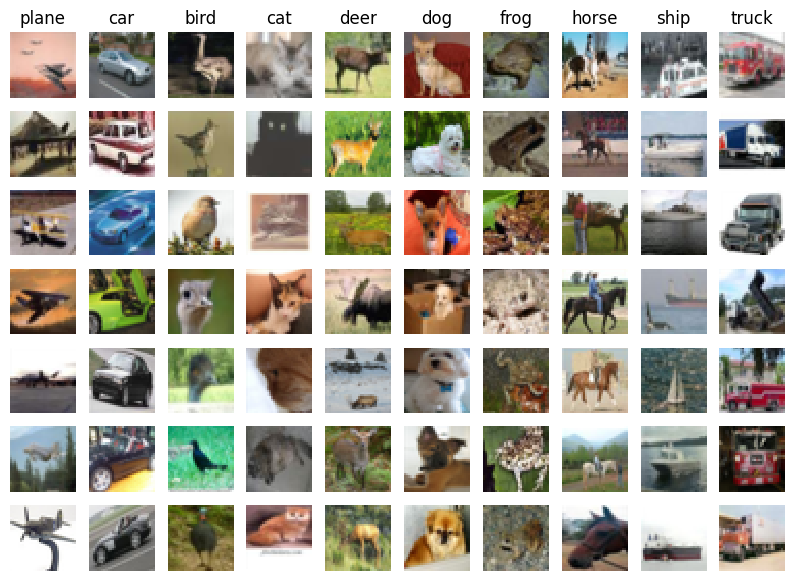

---------------- Training data ----------------
X_train shape: (45000, 32, 32, 3), y_train shape: (45000,)

---------------- Validation data ----------------
X_val shape: (5000, 32, 32, 3), y_val shape: (5000,)

---------------- Testing data ----------------
X_test shape: (10000, 32, 32, 3), y_test shape: (10000,)

---------------- Dataset info ----------------
Number of classes: 10
Number of features: 3072
Number of samples in dataset: 60000
Number of samples in training set: 45000, which is 75.00% of the dataset
Number of samples in validation set: 5000, which is 8.33% of the dataset
Number of samples in testing set: 10000, which is 16.67% of the dataset


In [2]:
import os
import torch

from utils import load_cifar10, reshape_to_vectors, dataset_stats, normalize_per_channel

notebook_dir = os.getcwd()
dataset_path = os.path.join(notebook_dir, 'data', 'datasets', 'CIFAR10')

# Download the CIFAR-10 dataset and show a few samples
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10(directory=dataset_path,
                                                              visualize_samples=True)

# Print out the dataset statistics
num_features, num_classes, num_samples = dataset_stats(X_train, y_train, X_val, y_val, X_test, y_test, verbose=True)

# Keep the original validation images for plotting
X_val_images = X_val.astype('uint8')

# Normalize each color channel with the mean and standard deviation of the training images
X_train, X_val, X_test = normalize_per_channel(X_train, X_val, X_test)

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).long()

X_val = torch.from_numpy(X_val).float()
y_val = torch.from_numpy(y_val).long()

X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).long()

# Reshape the images to vectors
X_train, X_val, X_test = reshape_to_vectors(X_train, X_val, X_test)

## From Arrows to Templates

In Part 1 every class had a weight vector $\mathbf{w}_c$ with 2 numbers, which we drew as an arrow. Here every image has $D = 3072$ values, so $\mathbf{W}$ has shape $(3072, 10)$ and every column $\mathbf{w}_c$ has 3072 numbers: one per pixel and color channel, exactly like an image. Reshaped back to 32×32×3, it becomes the **template** of class $c$.

The score of class $c$ is

$$s_c = \mathbf{x}\,\mathbf{w}_c + b_c = \sum_{i=1}^{3072} x_i\, w_{c,i} + b_c.$$

Every pixel value is multiplied by the template value at the same position, and the products are summed. The score is high when the image is bright (above average) where the template is positive and dark where the template is negative, in other words when the image **matches the template**. Since $\mathbf{x}\,\mathbf{w}_c = \lVert\mathbf{x}\rVert\,\lVert\mathbf{w}_c\rVert \cos\theta$, the dot product measures how similar the image and the template are.

The classifier predicts the class whose template matches best. Everything it knows about a class is stored in this **single template**.

### Sanity Check: The Loss Before Training

As in Part 1, the loss of an untrained classifier should be close to $\ln C$, now with $C = 10$ classes: $\ln 10 \approx 2.30$. Random initial weights make it somewhat higher.

In [3]:
import numpy as np
from assignments import LinearClassifier

torch.random.manual_seed(69)
untrained_classifier = LinearClassifier(num_features=num_features, num_classes=num_classes)

with torch.no_grad():
    initial_loss = untrained_classifier.loss(X_train, y_train).item()

print(f"Loss before training:          {initial_loss:.3f}")
print(f"Loss with equal scores, ln(C): {np.log(num_classes):.3f}")

Loss before training:          3.113
Loss with equal scores, ln(C): 2.303


## Training on Images

Compared with the 2D data of Part 1, everything is bigger: $D = 3072$ features instead of 2, $N = 45{,}000$ training images instead of 1,125 and $C = 10$ classes instead of 3.

### Training Configuration

- **Learning rate 0.01**, 10 times smaller than in Part 1. Every score now sums 3072 products, so the same step changes the scores much more. With 0.1, the validation accuracy drops to about 27%
- **Regularization 0.1**: keeps the templates smooth enough to be recognizable (more on this below)
- **4000 iterations with 400 images each**: about 35 passes through the training set. The validation accuracy stops improving after roughly 1500 iterations, and the classifier keeps the parameters with the best validation accuracy

Training: 100%|██████████| 4000/4000 [00:02<00:00, 1592.96it/s]


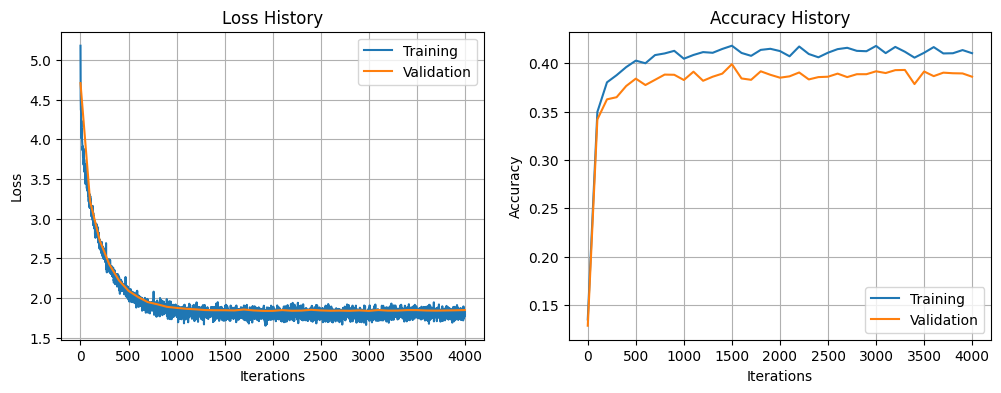

In [4]:
from utils import plot_training

torch.random.manual_seed(69)

# Create a linear classifier instance
linear_classifier = LinearClassifier(num_features=num_features,
                                     num_classes=num_classes,
                                     learning_rate=1e-2,
                                     reg=1e-1,
                                     num_iters=4000,
                                     batch_size=400)
# Train the classifier
loss_history, acc_history = linear_classifier.train(X_train, y_train, X_val, y_val)

# Visualize the training process
plot_training(loss_history, acc_history)

### How Well Does It Do?

We measure the training and validation accuracy and compare the classifier with k-NN:
- **Accuracy**: k-NN reached about 29% in Part 2 (on 8,000 training images, and about 34% with all 45,000). Random guessing gives 10%
- **Memory**: k-NN has to keep every training image, the linear classifier only $\mathbf{W}$ and $\mathbf{b}$

The confusion matrix shows which classes the classifier mixes up. Compare it with the k-NN confusion matrix from Part 2. The test set stays untouched until the very end.

Training accuracy:   41.8%
Validation accuracy: 39.9%

Numbers stored by k-NN:     138,240,000
Numbers stored by linear:        30,730


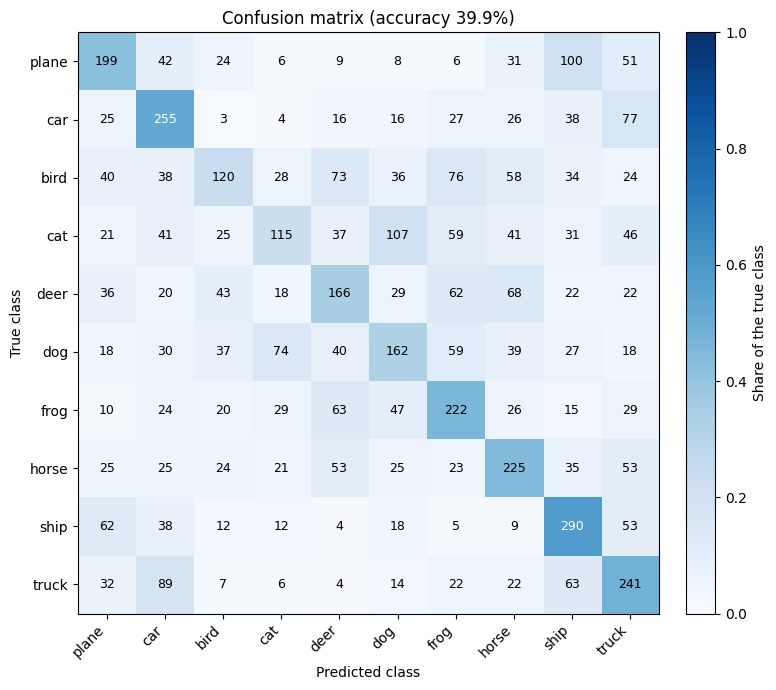

In [5]:
from sklearn.metrics import accuracy_score
from utils import plot_confusion_matrix

y_pred_val = linear_classifier.predict(X_val)
train_acc = accuracy_score(y_train, linear_classifier.predict(X_train))
val_acc = accuracy_score(y_val, y_pred_val)

print(f"Training accuracy:   {train_acc:.1%}")
print(f"Validation accuracy: {val_acc:.1%}")

# k-NN keeps every training image, the linear classifier only W and b
knn_numbers = X_train.numel()
linear_numbers = sum(param.numel() for param in linear_classifier.params.values())
print(f"\nNumbers stored by k-NN:    {knn_numbers:>12,}")
print(f"Numbers stored by linear:  {linear_numbers:>12,}")

# Rows are the true classes, columns are the predicted classes
plot_confusion_matrix(y_val, y_pred_val, classes)

## The Learned Templates

Below, every column of $\mathbf{W}$ is reshaped to 32×32×3 and shown as an image. Each template is rescaled on its own: its most negative weight is black and its most positive weight is white. A bright color at some position means that the class **wants** that color there; a dark color means the class wants the opposite.

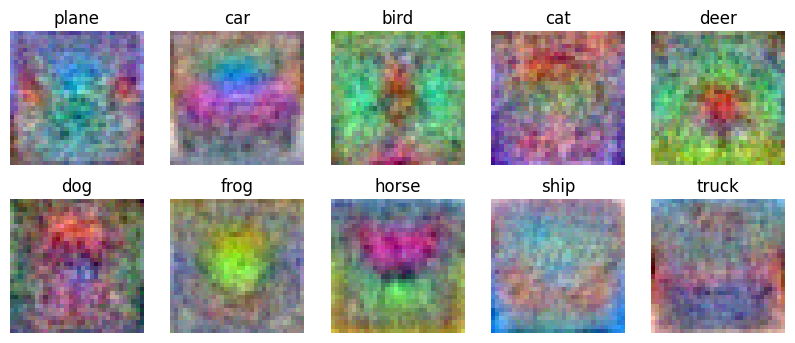

In [6]:
from utils import plot_weights_as_templates

plot_weights_as_templates(linear_classifier.params['W'], classes)

### What Do You See?

Look at each template and ask what an image must look like to score high:
- **Background colors**: which classes prefer blue at the top or around the object, and which prefer green or brown?
- **The object**: can you see a blob or a shape in the middle? Is it a single object or does it look mirrored?
- **Blurriness**: one template has to score well on *every* image of its class: every color, pose, position and background. It becomes a kind of average of all of them, so only what most images share survives

## Which Images Match Each Template?

Template matching is easiest to understand by looking at the images it prefers. For every class, the row below shows its template followed by the 8 validation images with the **highest score for that class**:
- A **green frame** is an image of that class: a good match
- A **red frame** is an image of another class, whose true class is written below it

Notice what the red images have in common with the template. Often it is not the object at all but the colors and the background.

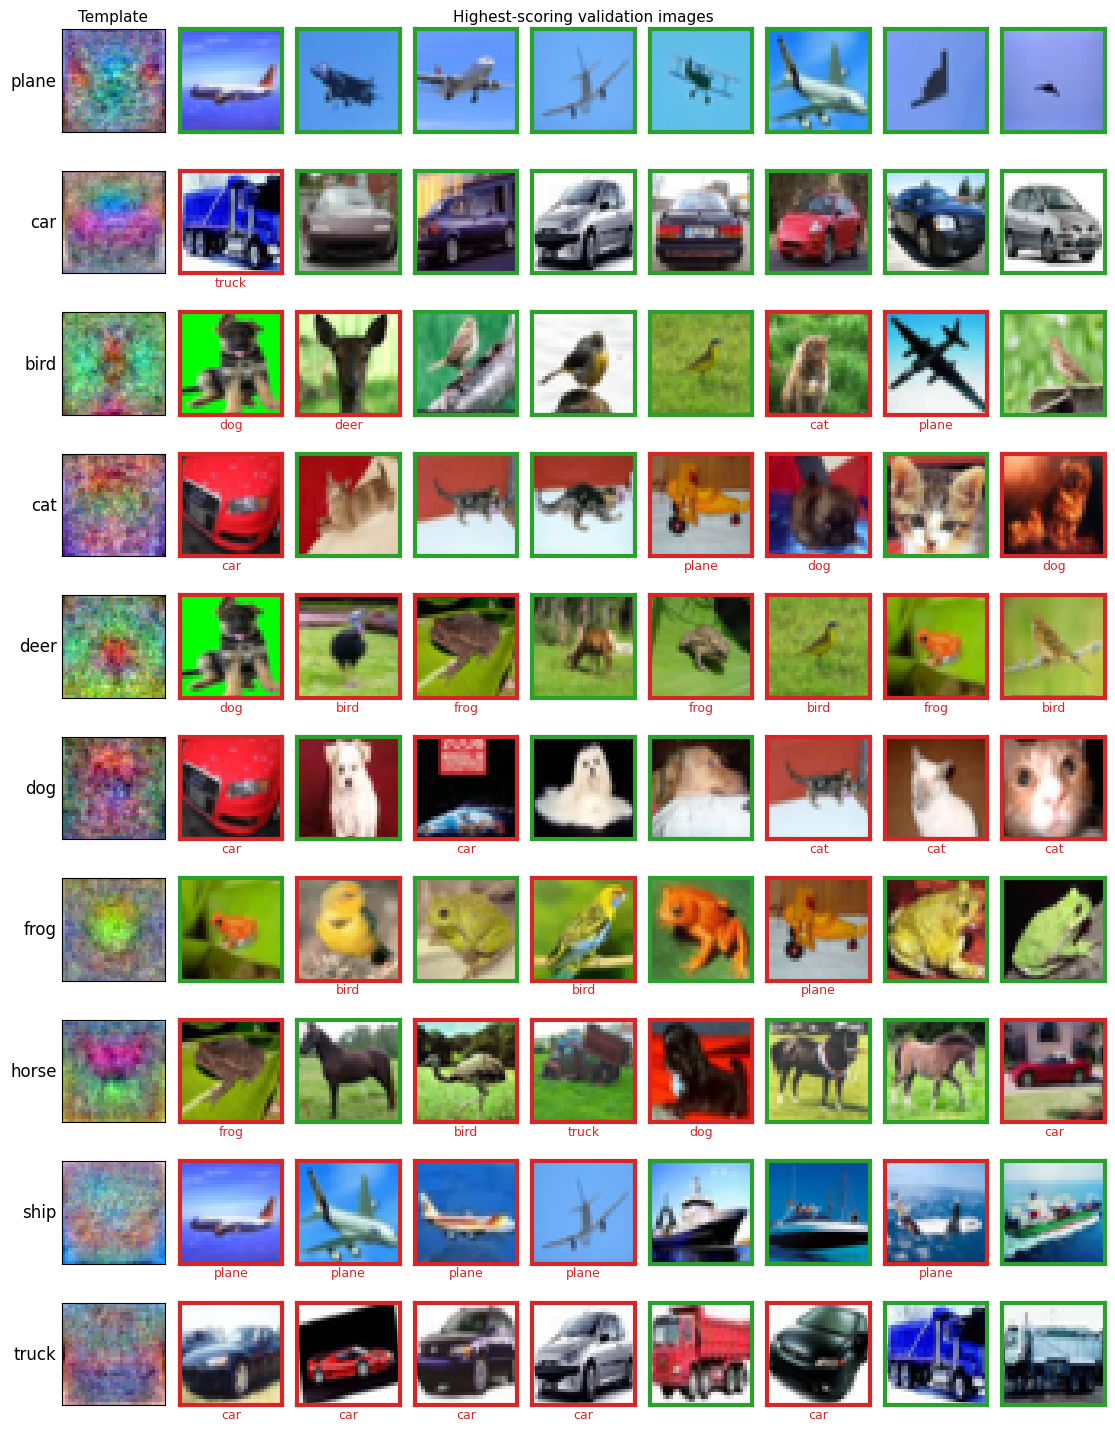

In [7]:
from utils import plot_template_matches

with torch.no_grad():
    val_scores = linear_classifier.forward(X_val)

plot_template_matches(linear_classifier.params['W'], val_scores, X_val_images, y_val, classes)

## Regularization Shapes the Templates

The L2 penalty $\lambda\sum\mathbf{W}^2$ pulls every weight toward zero. Without it, the classifier can use large weights on single pixels that happen to help on the training images, and the templates become noisy. We train with four regularization strengths and compare the templates, the size of the weights $\lVert\mathbf{W}\rVert$ and the accuracies. Each run takes a few seconds.

reg = 0    ||W|| = 4.46   training accuracy = 44.4%   validation accuracy = 40.2%
reg = 0.01 ||W|| = 2.84   training accuracy = 43.7%   validation accuracy = 40.4%
reg = 0.1  ||W|| = 0.77   training accuracy = 41.8%   validation accuracy = 39.9%
reg = 1    ||W|| = 0.29   training accuracy = 37.5%   validation accuracy = 36.5%


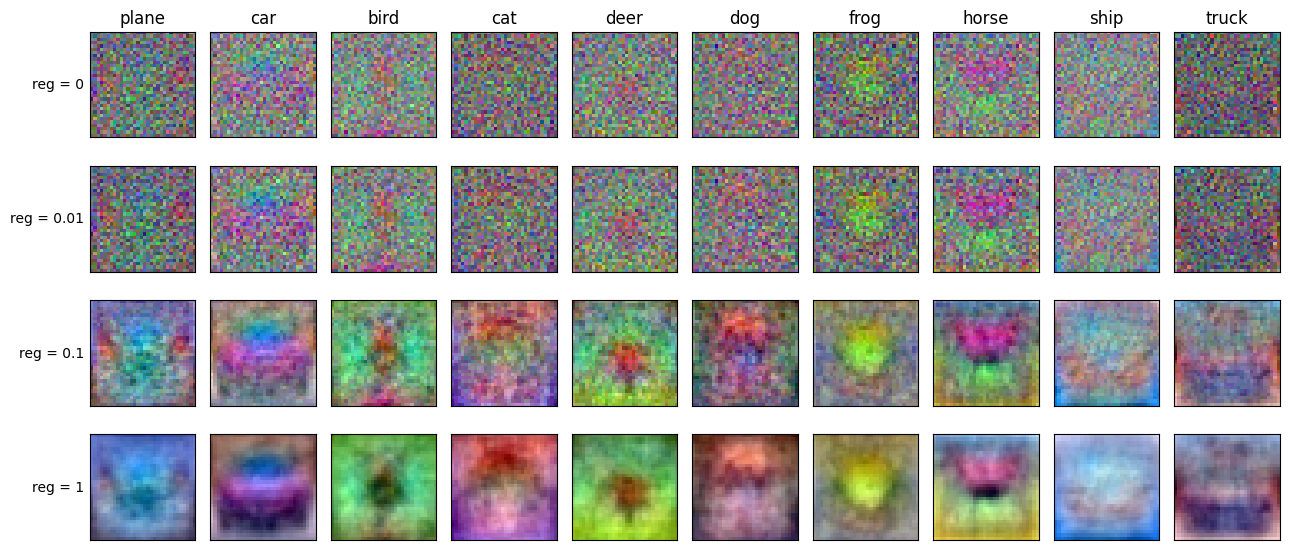

In [8]:
from utils import plot_template_comparison

regs = [0, 1e-2, 1e-1, 1]
reg_models = {}

for reg in regs:
    torch.random.manual_seed(69)
    model = LinearClassifier(num_features=num_features, num_classes=num_classes,
                             learning_rate=1e-2, reg=reg,
                             num_iters=4000, batch_size=400)
    model.train(X_train, y_train, X_val, y_val, verbose=False)
    reg_models[f"reg = {reg:g}"] = model

for name, model in reg_models.items():
    weight_norm = model.params['W'].norm().item()
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    val_accuracy = accuracy_score(y_val, model.predict(X_val))
    print(f"{name:10} ||W|| = {weight_norm:4.2f}   training accuracy = {train_accuracy:.1%}"
          f"   validation accuracy = {val_accuracy:.1%}")

plot_template_comparison({name: model.params['W'] for name, model in reg_models.items()}, classes)

Notice:
- Without regularization the templates are covered in pixel noise, yet the validation accuracy is about the same: the noise fits details of the training images that don't generalize
- Strong regularization gives smooth color blobs and the accuracy drops for both training and validation: the classifier is too constrained, it underfits
- The gap between training and validation accuracy is small for every run. With only 10 templates the classifier is too simple to memorize 45,000 images

## Testing the Limits of Template Matching

A template compares the image with itself **pixel by pixel, at fixed positions**. What happens if the object looks the same but appears at a different size or faces the other way? We transform every validation image in two ways that keep what the image shows:
- **Zoom in**: cut out the center of the image and resize it back to 32×32, so the object gets bigger
- **Flip** the image left to right, so the object faces the other way

The example is a horse seen from the side, which is clearly not symmetric.

Zoomed 1x: 39.9%
Zoomed 1.1x: 38.0%
Zoomed 1.25x: 35.7%
Zoomed 1.5x: 29.9%
Zoomed 2x: 24.1%
Flipped:      38.9%


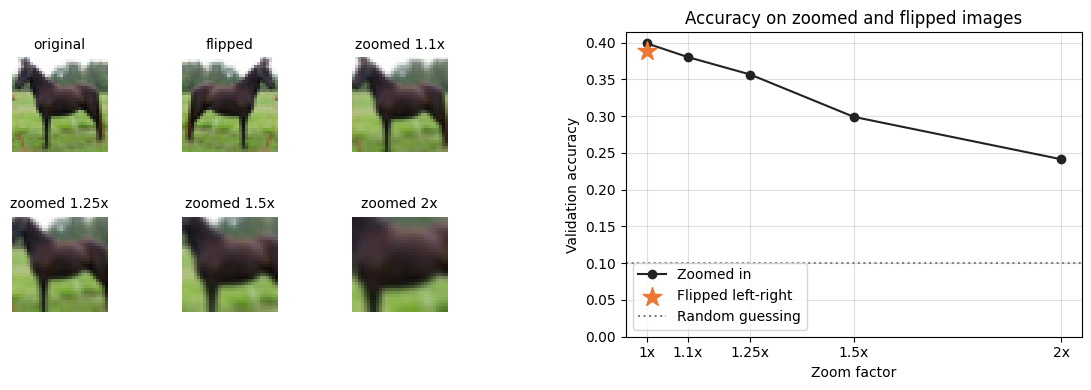

In [13]:
import torch.nn.functional as F
from utils import plot_transform_robustness


def zoom_in(images: torch.Tensor, factor: float) -> torch.Tensor:
    """Zoom into the center of images of shape (N, 32, 32, 3), keeping the size 32x32."""
    size = images.shape[1]
    crop = round(size / factor)
    start = (size - crop) // 2
    center = images[:, start:start + crop, start:start + crop, :]

    # F.interpolate expects the channels first: (N, 3, crop, crop)
    center = center.permute(0, 3, 1, 2)
    zoomed = F.interpolate(center, size=(size, size), mode='bilinear', align_corners=False)
    return zoomed.permute(0, 2, 3, 1)


def flip(images: torch.Tensor) -> torch.Tensor:
    """Flip images of shape (N, 32, 32, 3) left to right."""
    return torch.flip(images, dims=[2])


# Turn the vectors back into images of shape (N, 32, 32, 3)
val_images = X_val.reshape(-1, 32, 32, 3)

zoom_factors = [1, 1.1, 1.25, 1.5, 2]
zoom_accuracies = []
for factor in zoom_factors:
    zoomed = zoom_in(val_images, factor).reshape(len(val_images), -1)
    zoom_accuracies.append(accuracy_score(y_val, linear_classifier.predict(zoomed)))

flipped = flip(val_images).reshape(len(val_images), -1)
flip_accuracy = accuracy_score(y_val, linear_classifier.predict(flipped))

for factor, accuracy in zip(zoom_factors, zoom_accuracies):
    print(f"Zoomed {factor:g}x: {accuracy:.1%}")
print(f"Flipped:      {flip_accuracy:.1%}")

# The horse that best matches the horse template (original pixels, for display only)
horse_index = int(torch.argmax(torch.where(y_val == 7, val_scores[:, 7], -torch.inf)))
horse = torch.from_numpy(X_val_images[horse_index:horse_index + 1]).float()

examples = {"original": horse[0], "flipped": flip(horse)[0]}
for factor in zoom_factors[1:]:
    examples[f"zoomed {factor:g}x"] = zoom_in(horse, factor)[0]

plot_transform_robustness(examples, zoom_factors, zoom_accuracies, flip_accuracy)

Notice:
- Zooming in keeps the object and only makes it bigger, yet the accuracy drops quickly. The object no longer fills the region where the template expects it
- Flipping barely matters, even for classes like horses or planes that are photographed from the side. The training set contains them facing both ways, and a single template has to match both, so it mixes both directions (look at the horse template)
- A better model would recognize a pattern **wherever and however large** it appears. Convolutional networks take a big step in this direction: they slide small templates over the whole image

## Final Evaluation on the Test Set

All choices are made. We pick the classifier with the best validation accuracy from the regularization experiment and evaluate it **once** on the test set.

In [14]:
# Choose the classifier with the best validation accuracy
val_accuracies = {name: accuracy_score(y_val, model.predict(X_val))
                  for name, model in reg_models.items()}
best_name = max(val_accuracies, key=val_accuracies.get)

# Only now, and only once, look at the test set
test_acc = accuracy_score(y_test, reg_models[best_name].predict(X_test))

print(f"Chosen classifier:   {best_name}")
print(f"Validation accuracy: {val_accuracies[best_name]:.1%}")
print(f"Test accuracy:       {test_acc:.1%}")

Chosen classifier:   reg = 0.01
Validation accuracy: 40.4%
Test accuracy:       40.2%


## Summary and Next Steps

### Key Takeaways

- A linear classifier on images is **template matching**: every class has one template image, and the class whose template matches the image best wins
- The templates are blurry averages of everything a class can look like, so they rely heavily on **colors and backgrounds**
- **Regularization** trades noisy templates for smooth ones; too much of it makes the classifier underfit
- Templates compare pixels at **fixed positions**, so the same object at a different size already hurts, while flipping barely matters because the templates mix both directions

### Performance on CIFAR-10

| Classifier | Accuracy |
|---|---|
| Random guessing | 10% |
| k-NN (Part 2) | about 30% |
| Linear classifier (this notebook) | about 40% |
| MLP (next notebooks) | about 50% |
| Modern convolutional networks | over 99% |

### Why One Template Is Not Enough

A car can be red or blue, seen from the side or the front, small or large, on the left or on the right of the image. One template per class has to cover all of these at once. The fixes are the topic of the next notebooks:
1. **More templates**: the first layer of an MLP computes many template scores, for example one for red cars facing left and another for blue cars facing right, and the next layer combines them. The MLP learns these templates itself
2. **Templates that slide**: convolutional networks match small templates at every position of the image, so an object is found wherever it appears in the image